# M1 Retrieval — Analysis

Reads `task3_m1_retrieval.csv` and produces:
- Retrieval rates by class type × variant
- Rank distributions
- Per-class breakdown
- Decision: which variant wins?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

CSV = Path('/home/ishana/scratch/results/task3_m1_retrieval.csv')
PLOTS = Path('/home/ishana/scratch/results')

df = pd.read_csv(CSV)
df['retrieved'] = df['retrieved'].astype(bool)
print(f'Rows: {len(df)}')
print(f'Class types: {df["class_type"].unique()}')
print(f'Variants: {df["variant"].unique()}')
print(f'Classes: {df["class_id"].nunique()}')
df.head()

Rows: 1418
Class types: ['paraphrase' 'entity']
Variants: ['simple' 'hotflip']
Classes: 120


,class_id,class_type,variant,query_idx,query_text,retrieved,rank,blocker_sim,threshold_sim,d_r_text
0,test1,paraphrase,simple,0,how many episodes are in chicago fire season 4,False,NaN,0.65103,0.79554,How many episodes make up Chicago Fire Season 4?
1,test1,paraphrase,simple,1,How many episodes make up Chicago Fire Season 4?,False,NaN,0.68212,0.78851,How many episodes make up Chicago Fire Season 4?
2,test1,paraphrase,simple,2,What is the total number of episodes in Chicag...,False,NaN,0.65053,0.79449,How many episodes make up Chicago Fire Season 4?
3,test1,paraphrase,simple,3,"In season 4 of Chicago Fire, how many episodes...",False,NaN,0.65009,0.79640,How many episodes make up Chicago Fire Season 4?
4,test1,paraphrase,simple,4,What is the episode count for the fourth seaso...,False,NaN,0.64285,0.77933,How many episodes make up Chicago Fire Season 4?


## 1. Overall Retrieval Rates

In [2]:
summary = (
    df.groupby(['class_type', 'variant'])['retrieved']
    .agg(['sum', 'count', 'mean'])
    .rename(columns={'sum': 'n_retrieved', 'count': 'n_total', 'mean': 'rate'})
    .reset_index()
)
summary['rate_pct'] = (summary['rate'] * 100).round(1)
print(summary.to_string(index=False))

print("\nTargets: paraphrase ≥90%, entity ≥70%")
targets = {'paraphrase': 90.0, 'entity': 70.0}
for _, row in summary.iterrows():
    target = targets[row['class_type']]
    status = '✓ PASS' if row['rate_pct'] >= target else '✗ FAIL'
    print(f"  {row['class_type']}/{row['variant']}: {row['rate_pct']}%  {status}")

class_type variant  n_retrieved  n_total     rate  rate_pct
    entity hotflip            8      109 0.073394       7.3
    entity  simple           15      109 0.137615      13.8
paraphrase hotflip          348      600 0.580000      58.0
paraphrase  simple          240      600 0.400000      40.0

Targets: paraphrase ≥90%, entity ≥70%
  entity/hotflip: 7.3%  ✗ FAIL
  entity/simple: 13.8%  ✗ FAIL
  paraphrase/hotflip: 58.0%  ✗ FAIL
  paraphrase/simple: 40.0%  ✗ FAIL


## 2. Retrieval Rate Bar Chart

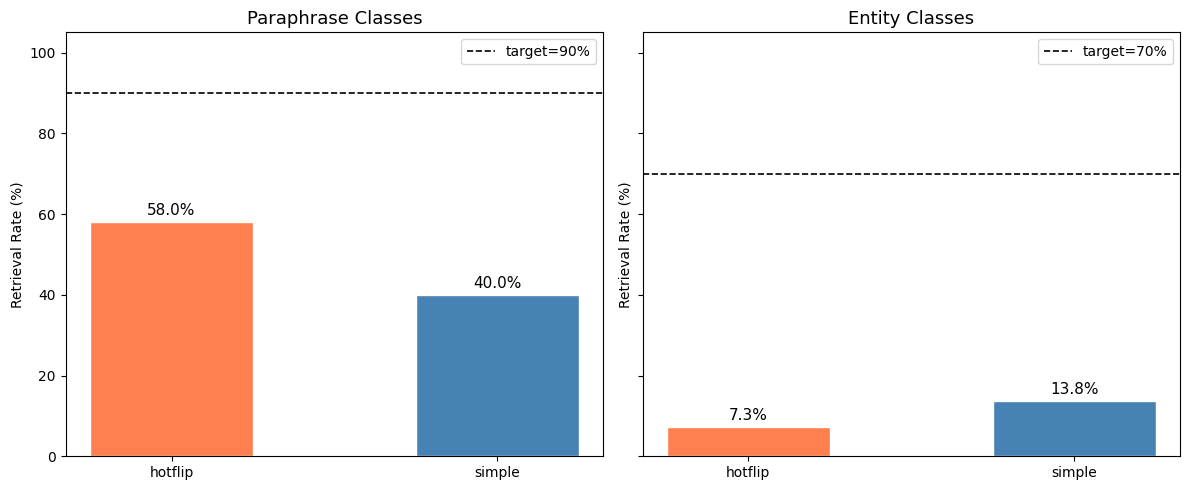

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
colors = {'simple': 'steelblue', 'hotflip': 'coral'}

for ax, ctype in zip(axes, ['paraphrase', 'entity']):
    sub = summary[summary['class_type'] == ctype]
    x = range(len(sub))
    bars = ax.bar(
        [row['variant'] for _, row in sub.iterrows()],
        sub['rate_pct'],
        color=[colors[v] for v in sub['variant']],
        width=0.5,
        edgecolor='white',
    )
    target = 90 if ctype == 'paraphrase' else 70
    ax.axhline(target, color='black', linestyle='--', linewidth=1.2,
               label=f'target={target}%')
    ax.set_ylim(0, 105)
    ax.set_title(f'{ctype.capitalize()} Classes', fontsize=13)
    ax.set_ylabel('Retrieval Rate (%)')
    ax.legend()
    for bar, (_, row) in zip(bars, sub.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f"{row['rate_pct']:.1f}%", ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig(PLOTS / 'm1_retrieval_rates.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Rank Distributions

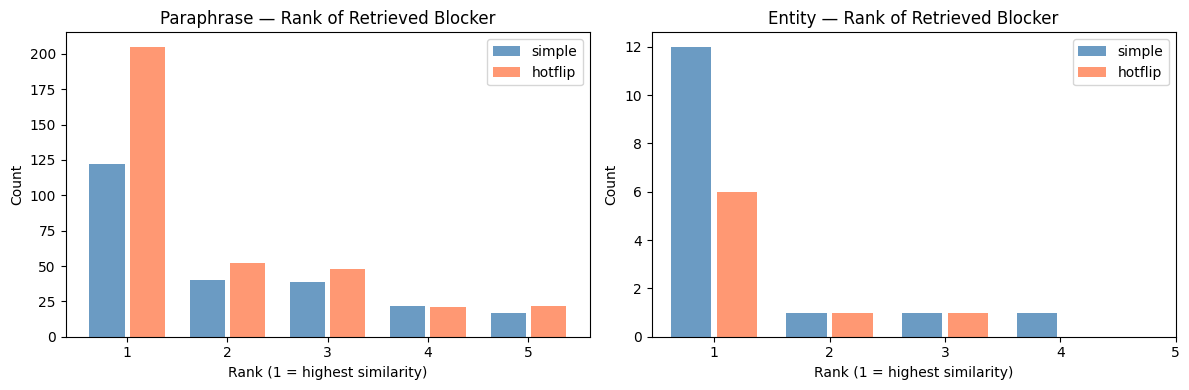

In [4]:
# Rank distribution for retrieved queries
retrieved_df = df[df['retrieved'] == True].copy()
retrieved_df['rank'] = retrieved_df['rank'].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, ctype in zip(axes, ['paraphrase', 'entity']):
    for variant, color in colors.items():
        sub = retrieved_df[
            (retrieved_df['class_type'] == ctype) & (retrieved_df['variant'] == variant)
        ]
        if len(sub) == 0:
            continue
        ranks = sub['rank'].value_counts().sort_index()
        ax.bar(
            [r - 0.2 + (0.4 if variant == 'hotflip' else 0) for r in ranks.index],
            ranks.values,
            width=0.35, label=variant, color=color, alpha=0.8,
        )
    ax.set_title(f'{ctype.capitalize()} — Rank of Retrieved Blocker', fontsize=12)
    ax.set_xlabel('Rank (1 = highest similarity)')
    ax.set_ylabel('Count')
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.legend()

plt.tight_layout()
plt.savefig(PLOTS / 'm1_rank_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. HotFlip vs Simple: Per-class delta

Classes where HotFlip > Simple: 48
Classes where Simple > HotFlip: 13
Classes equal: 59


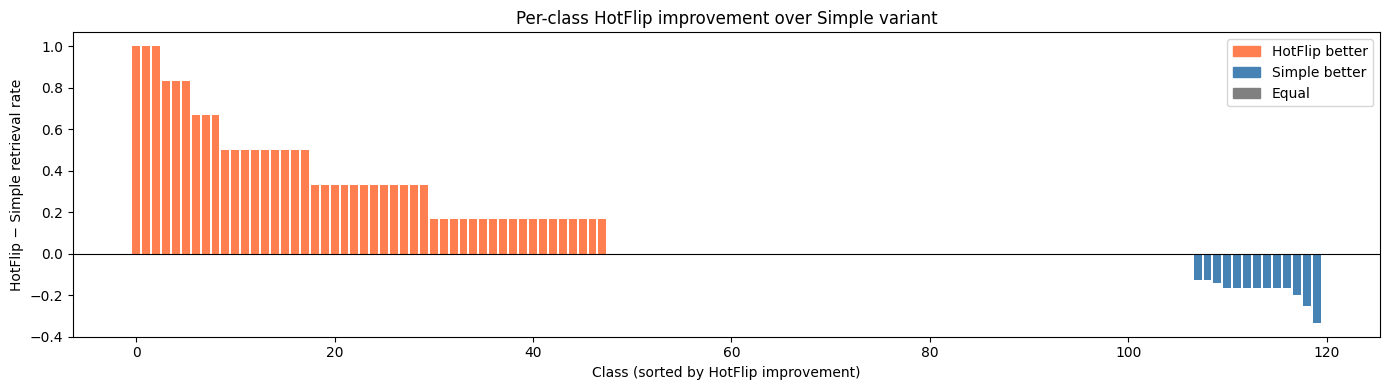

In [5]:
# For each class, compare simple vs hotflip retrieval rate
per_class = (
    df.groupby(['class_id', 'class_type', 'variant'])['retrieved']
    .mean()
    .unstack('variant')
    .reset_index()
)
per_class['delta'] = per_class['hotflip'] - per_class['simple']
per_class = per_class.sort_values('delta', ascending=False)

print('Classes where HotFlip > Simple:', (per_class['delta'] > 0).sum())
print('Classes where Simple > HotFlip:', (per_class['delta'] < 0).sum())
print('Classes equal:', (per_class['delta'] == 0).sum())

fig, ax = plt.subplots(figsize=(14, 4))
colors_bar = ['coral' if d > 0 else ('steelblue' if d < 0 else 'gray')
              for d in per_class['delta']]
ax.bar(range(len(per_class)), per_class['delta'], color=colors_bar)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Class (sorted by HotFlip improvement)')
ax.set_ylabel('HotFlip − Simple retrieval rate')
ax.set_title('Per-class HotFlip improvement over Simple variant')

# Colour legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='coral', label='HotFlip better'),
    Patch(color='steelblue', label='Simple better'),
    Patch(color='gray', label='Equal'),
])
plt.tight_layout()
plt.savefig(PLOTS / 'm1_delta_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Blocker Similarity Distribution

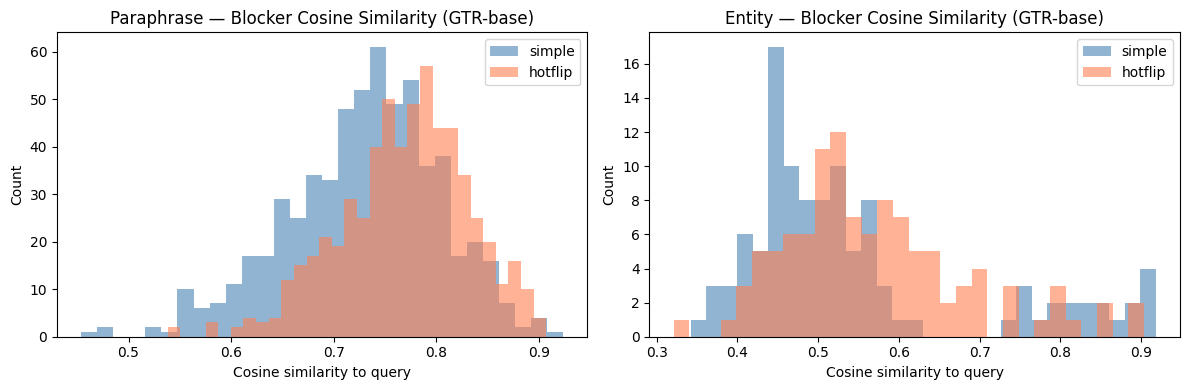

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, ctype in zip(axes, ['paraphrase', 'entity']):
    for variant, color in colors.items():
        sub = df[(df['class_type'] == ctype) & (df['variant'] == variant)]
        ax.hist(sub['blocker_sim'], bins=30, alpha=0.6, color=color, label=variant)
    ax.set_title(f'{ctype.capitalize()} — Blocker Cosine Similarity (GTR-base)')
    ax.set_xlabel('Cosine similarity to query')
    ax.set_ylabel('Count')
    ax.legend()
plt.tight_layout()
plt.savefig(PLOTS / 'm1_blocker_sim.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Decision: Which Variant for the Paper?

In [7]:
print('=' * 60)
print('M1 RETRIEVAL — DECISION SUMMARY')
print('=' * 60)
print()

for ctype in ['paraphrase', 'entity']:
    target = 90 if ctype == 'paraphrase' else 70
    print(f'{ctype.upper()} CLASSES (target ≥{target}%)')
    for variant in ['simple', 'hotflip']:
        sub = summary[(summary['class_type'] == ctype) & (summary['variant'] == variant)]
        if len(sub) == 0:
            continue
        rate = float(sub['rate_pct'])
        n_ret = int(sub['n_retrieved'])
        n_tot = int(sub['n_total'])
        status = '✓ PASS' if rate >= target else '✗ FAIL'
        print(f'  {variant:10s}: {rate:.1f}% ({n_ret}/{n_tot})  {status}')
    print()

# Determine winner
simple_para = float(summary[(summary['class_type']=='paraphrase') & (summary['variant']=='simple')]['rate_pct'])
hotflip_para = float(summary[(summary['class_type']=='paraphrase') & (summary['variant']=='hotflip')]['rate_pct'])
simple_ent = float(summary[(summary['class_type']=='entity') & (summary['variant']=='simple')]['rate_pct'])
hotflip_ent = float(summary[(summary['class_type']=='entity') & (summary['variant']=='hotflip')]['rate_pct'])

print('DECISION:')
if hotflip_para >= simple_para and hotflip_ent >= simple_ent:
    print('  HotFlip dominates: use HotFlip for both class types.')
elif simple_para >= hotflip_para and simple_ent >= hotflip_ent:
    print('  Simple dominates: use Simple for both. HotFlip adds cost without gain.')
else:
    better_para = 'hotflip' if hotflip_para > simple_para else 'simple'
    better_ent = 'hotflip' if hotflip_ent > simple_ent else 'simple'
    print(f'  Trade-off: {better_para} for paraphrase classes, {better_ent} for entity classes.')
    print(f'  Recommendation: use HotFlip for entity (harder case), Simple for paraphrase.')

print()
print(f'Simple improvement over naive (query-prepend): see paper baseline.')
print(f'HotFlip overhead: ~25s per class on L40S (200 iters, batch_size=32).')

M1 RETRIEVAL — DECISION SUMMARY

PARAPHRASE CLASSES (target ≥90%)
  simple    : 40.0% (240/600)  ✗ FAIL
  hotflip   : 58.0% (348/600)  ✗ FAIL

ENTITY CLASSES (target ≥70%)
  simple    : 13.8% (15/109)  ✗ FAIL
  hotflip   : 7.3% (8/109)  ✗ FAIL

DECISION:
  Trade-off: hotflip for paraphrase classes, simple for entity classes.
  Recommendation: use HotFlip for entity (harder case), Simple for paraphrase.

Simple improvement over naive (query-prepend): see paper baseline.
HotFlip overhead: ~25s per class on L40S (200 iters, batch_size=32).


/tmp/ipykernel_3076997/776869439.py:13: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  rate = float(sub['rate_pct'])
/tmp/ipykernel_3076997/776869439.py:14: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  n_ret = int(sub['n_retrieved'])
/tmp/ipykernel_3076997/776869439.py:15: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  n_tot = int(sub['n_total'])
/tmp/ipykernel_3076997/776869439.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  simple_para = float(summary[(summary['class_type']=='paraphrase') & (summary['variant']=='simple')]['rate_pct'])
/tmp/ipykernel_3076997/776869439.py:22: FutureWarning: Calling fl